# Model Selection and Hyperparameter Tuning

When you apply machine learning to a real problem, you often have an idea of what general _family_ of models to try. But you'll often want to try a few different options to determine which one will work best. Should you use a k-nearest-neighbors classifier? A decision tree? A support vector machine? The honest answer is usually: try several and let the data tell you.

Then, once you have a promising architecture, you still need to decide on its configuration — the **hyperparameters** that control how the model learns. For k-NN that is the number of neighbors; for a decision tree it is the maximum depth; for an SVM it is the regularization strength C and the kernel choice.

This notebook covers both steps:

1. **Architecture comparison** — how to run multiple model types through the same cross-validation harness and rank them objectively.
2. **Hyperparameter tuning** — how to systematically search the hyperparameter space of your chosen model and find the configuration that generalizes best.

In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import warnings
warnings.filterwarnings("ignore")

from sklearn.datasets import load_wine
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

import ipywidgets as widgets
from IPython.display import display

## The Dataset

We will use the **Wine dataset** built into scikit-learn. It contains 178 wine samples from three Italian wineries, each described by 13 chemical measurements (alcohol content, ash, color intensity, and so on). The goal is to predict which winery a wine came from.

It is a useful benchmark for comparing classifiers: it has enough features that some models will struggle, and three classes instead of two, which tests whether a model handles multi-class problems gracefully.

In [3]:
wine = load_wine()
X, y = wine.data, wine.target

print(f"Samples: {X.shape[0]},  Features: {X.shape[1]},  Classes: {len(wine.target_names)}")
print(f"Class names: {wine.target_names}")
print(f"Feature names: {wine.feature_names}")

Samples: 178,  Features: 13,  Classes: 3
Class names: ['class_0' 'class_1' 'class_2']
Feature names: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


## Part 1: Comparing Model Architectures

The standard way to compare models fairly is **cross-validation**: split the data into *k* folds, train on *k−1* of them, test on the held-out fold, and rotate through all folds. The average score across folds is a low-variance estimate of how well the model would do on truly new data.

Notice that we wrap each classifier in a `Pipeline` with a `StandardScaler`. This is important: many models (especially k-NN and SVM) are sensitive to feature scale. Running the scaler inside the pipeline ensures that it is *fit only on training folds* — never on the test fold — which would otherwise leak information and inflate your accuracy estimate.

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

candidates = {
    "k-NN (k=3)":          Pipeline([("scaler", StandardScaler()), ("clf", KNeighborsClassifier(n_neighbors=3))]),
    "Logistic Regression": Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=1000))]),
    "Decision Tree":       Pipeline([("scaler", StandardScaler()), ("clf", DecisionTreeClassifier(random_state=42))]),
    "Random Forest":       Pipeline([("scaler", StandardScaler()), ("clf", RandomForestClassifier(n_estimators=100, random_state=42))]),
    "SVM (RBF kernel)":    Pipeline([("scaler", StandardScaler()), ("clf", SVC(kernel="rbf"))]),
}

results = {}
for name, pipe in candidates.items():
    scores = cross_val_score(pipe, X, y, cv=cv, scoring="accuracy")
    results[name] = scores
    print(f"{name:25s}  mean={scores.mean():.3f}  std={scores.std():.3f}")

k-NN (k=3)                 mean=0.966  std=0.021
Logistic Regression        mean=0.983  std=0.014
Decision Tree              mean=0.899  std=0.029
Random Forest              mean=0.977  std=0.021
SVM (RBF kernel)           mean=0.983  std=0.022


Text(0.5, 0, '5-fold cross-validation accuracy')

Text(0.5, 1.0, 'Model Architecture Comparison — Wine Dataset')

(0.7, 1.02)

Text(0.9711904761904762, 0.0, '0.966')

Text(0.9883333333333332, 1.0, '0.983')

Text(0.9038888888888889, 2.0, '0.899')

Text(0.9824603174603176, 3.0, '0.977')

Text(0.9883333333333332, 4.0, '0.983')

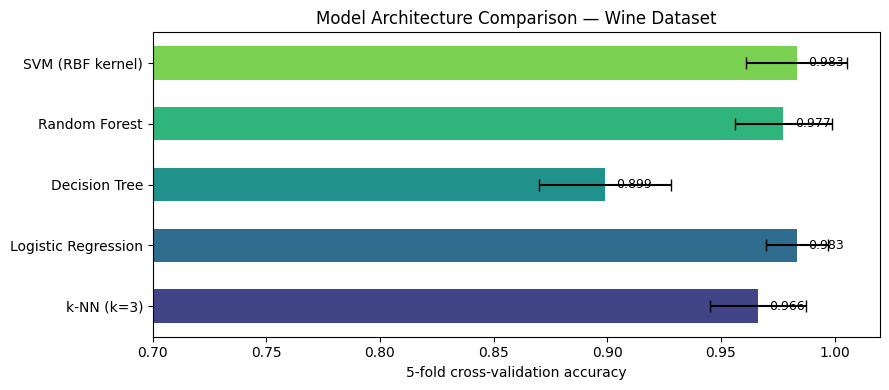

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))

names  = list(results.keys())
means  = [results[n].mean() for n in names]
stds   = [results[n].std()  for n in names]
colors = cm.viridis(np.linspace(0.2, 0.8, len(names)))

bars = ax.barh(names, means, xerr=stds, color=colors, capsize=4, height=0.55)
ax.set_xlabel("5-fold cross-validation accuracy")
ax.set_title("Model Architecture Comparison — Wine Dataset")
ax.set_xlim(0.7, 1.02)

for bar, mean in zip(bars, means):
    ax.text(mean + 0.005, bar.get_y() + bar.get_height()/2,
            f"{mean:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

The error bars show one standard deviation across the five folds. A model with a high mean but also a wide bar is less reliable — its performance depended on which fold happened to be the held-out one. Prefer models that score well *and* have tight bars.

### Interactive: Adjust the number of CV folds

More folds gives a less biased estimate (each model is trained on more data per fold) but adds variance between runs. Five to ten folds is the standard range.

In [6]:
def compare_models(n_folds):
    cv_int = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    res = {}
    for name, pipe in candidates.items():
        scores = cross_val_score(pipe, X, y, cv=cv_int, scoring="accuracy")
        res[name] = scores

    names  = list(res.keys())
    means  = [res[n].mean() for n in names]
    stds   = [res[n].std()  for n in names]
    colors = cm.viridis(np.linspace(0.2, 0.8, len(names)))

    fig, ax = plt.subplots(figsize=(9, 4))
    bars = ax.barh(names, means, xerr=stds, color=colors, capsize=4, height=0.55)
    ax.set_xlabel(f"{n_folds}-fold cross-validation accuracy")
    ax.set_title(f"Model Comparison with {n_folds}-fold CV")
    ax.set_xlim(0.7, 1.02)
    for bar, mean in zip(bars, means):
        ax.text(mean + 0.005, bar.get_y() + bar.get_height()/2,
                f"{mean:.3f}", va="center", fontsize=9)
    plt.tight_layout()
    plt.show()

folds_slider = widgets.IntSlider(value=5, min=3, max=15, step=1,
                                  description="CV folds:",
                                  style={"description_width": "80px"})
widgets.interact(compare_models, n_folds=folds_slider)

interactive(children=(IntSlider(value=5, description='CV folds:', max=15, min=3, style=SliderStyle(description…

<function __main__.compare_models(n_folds)>

## Part 2: Hyperparameter Tuning

Once you have picked a promising architecture, the next question is: what is the best *configuration* of that model?

Every model has knobs that are not learned from the data — these are **hyperparameters**. Examples:

| Model | Key hyperparameters |
|---|---|
| k-NN | Number of neighbors k, distance metric |
| Decision Tree | Max depth, min samples per leaf |
| SVM | Regularization strength C, kernel type, gamma |
| Logistic Regression | Regularization strength C, penalty type |

The naive approach — try a few values by hand and pick the best test score — overfits the test set. You are effectively using the test data to make a modeling decision, which means the test score is no longer an unbiased estimate of generalization.

**Grid search with cross-validation** is the principled alternative: define a grid of candidate hyperparameter values, evaluate every combination using cross-validation on the training data only, and select the combination with the best average score. The held-out test set stays untouched until the very end.

### Example: Tuning SVM

SVM has two main hyperparameters for the RBF kernel:

- **C** — controls the trade-off between margin width and training errors. Small C allows more misclassifications in exchange for a wider margin. Large C pushes toward fewer training errors but risks overfitting.
- **gamma** — controls how far the influence of a single training point reaches. Small gamma means far reach and a smoother boundary. Large gamma means short reach and a more complex boundary.

We search a grid of both simultaneously.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    SVC(kernel="rbf")),
])

param_grid = {
    "clf__C":     [0.01, 0.1, 1, 10, 100],
    "clf__gamma": [0.001, 0.01, 0.1, 1],
}

grid_search = GridSearchCV(
    svm_pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    return_train_score=True,
    n_jobs=-1,
)

grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV accuracy:  {grid_search.best_score_:.3f}")
print(f"Test accuracy:     {grid_search.score(X_test, y_test):.3f}")

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('clf', SVC())]),
             n_jobs=-1,
             param_grid={'clf__C': [0.01, 0.1, 1, 10, 100],
                         'clf__gamma': [0.001, 0.01, 0.1, 1]},
             return_train_score=True, scoring='accuracy')

Best parameters: {'clf__C': 1, 'clf__gamma': 0.01}
Best CV accuracy:  0.993
Test accuracy:     1.000


The `clf__` prefix (double underscore) is how sklearn pipelines refer to parameters of a named step. `clf__C` means the `C` parameter of the step called `clf`.

`GridSearchCV` tries every combination: 5 choices for C × 4 choices for gamma = 20 combinations, each evaluated over 5 folds = 100 model fits in total. `n_jobs=-1` runs them in parallel using all available CPU cores.

[Text(0, 0, '0.001'), Text(1, 0, '0.01'), Text(2, 0, '0.1'), Text(3, 0, '1')]

[Text(0, 0, '0.01'),
 Text(0, 1, '0.1'),
 Text(0, 2, '1'),
 Text(0, 3, '10'),
 Text(0, 4, '100')]

Text(0.5, 0, 'gamma')

Text(0, 0.5, 'C')

Text(0.5, 1.0, 'Mean CV Accuracy — SVM Grid Search')

...

Text(3, 3, '0.63')

Text(0, 4, '0.98')

Text(1, 4, '0.99')

Text(2, 4, '0.99')

Text(3, 4, '0.63')

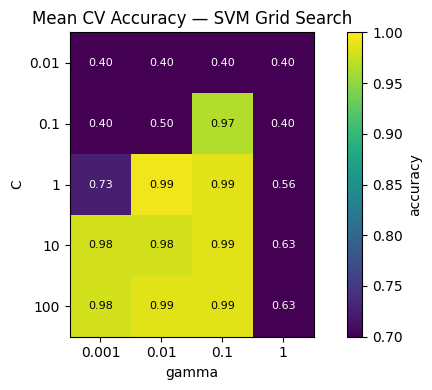

In [8]:
results_df = pd.DataFrame(grid_search.cv_results_)
C_vals     = param_grid["clf__C"]
gamma_vals = param_grid["clf__gamma"]

mean_scores = results_df["mean_test_score"].values.reshape(len(C_vals), len(gamma_vals))

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(mean_scores, cmap="viridis", vmin=0.7, vmax=1.0)
ax.set_xticks(range(len(gamma_vals)))
ax.set_xticklabels(gamma_vals)
ax.set_yticks(range(len(C_vals)))
ax.set_yticklabels(C_vals)
ax.set_xlabel("gamma")
ax.set_ylabel("C")
ax.set_title("Mean CV Accuracy — SVM Grid Search")
fig.colorbar(im, ax=ax, label="accuracy")

for i in range(len(C_vals)):
    for j in range(len(gamma_vals)):
        ax.text(j, i, f"{mean_scores[i, j]:.2f}",
                ha="center", va="center", fontsize=8,
                color="white" if mean_scores[i, j] < 0.85 else "black")

plt.tight_layout()
plt.show()

The heat map shows you the accuracy landscape: bright cells are good combinations, dark cells are bad ones. Regions where neighboring cells are all bright suggest the model is robust to the exact value — you have flexibility. A single isolated bright cell suggests performance depends on hitting a narrow sweet spot, which may not hold up on new data.

### Interactive: Explore different models and their hyperparameter grids

Use the dropdown to switch between models. The grid search reruns on the training data and shows the best parameters, best CV accuracy, and a visualization of the search landscape.

In [9]:
model_configs = {
    "SVM (RBF)": {
        "pipeline": Pipeline([("scaler", StandardScaler()), ("clf", SVC(kernel="rbf"))]),
        "grid": {"clf__C": [0.01, 0.1, 1, 10, 100], "clf__gamma": [0.001, 0.01, 0.1, 1]},
        "x_param": "clf__C", "hue_param": "clf__gamma",
    },
    "SVM (linear)": {
        "pipeline": Pipeline([("scaler", StandardScaler()), ("clf", SVC(kernel="linear"))]),
        "grid": {"clf__C": [0.001, 0.01, 0.1, 1, 10, 100]},
        "x_param": "clf__C", "hue_param": None,
    },
    "k-NN": {
        "pipeline": Pipeline([("scaler", StandardScaler()), ("clf", KNeighborsClassifier())]),
        "grid": {"clf__n_neighbors": list(range(1, 21)), "clf__metric": ["euclidean", "manhattan"]},
        "x_param": "clf__n_neighbors", "hue_param": "clf__metric",
    },
    "Decision Tree": {
        "pipeline": Pipeline([("scaler", StandardScaler()), ("clf", DecisionTreeClassifier(random_state=42))]),
        "grid": {"clf__max_depth": [1, 2, 3, 5, 8, 12, None], "clf__min_samples_leaf": [1, 2, 5, 10]},
        "x_param": "clf__max_depth", "hue_param": "clf__min_samples_leaf",
    },
    "Logistic Regression": {
        "pipeline": Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=2000))]),
        "grid": {"clf__C": [0.001, 0.01, 0.1, 1, 10, 100], "clf__penalty": ["l1", "l2"], "clf__solver": ["saga"]},
        "x_param": "clf__C", "hue_param": "clf__penalty",
    },
}

def run_grid_search(model_name):
    cfg = model_configs[model_name]
    gs  = GridSearchCV(cfg["pipeline"], cfg["grid"], cv=5,
                       scoring="accuracy", return_train_score=True, n_jobs=-1)
    gs.fit(X_train, y_train)

    print(f"Best params:   {gs.best_params_}")
    print(f"Best CV acc:   {gs.best_score_:.3f}")
    print(f"Test accuracy: {gs.score(X_test, y_test):.3f}")

    df    = pd.DataFrame(gs.cv_results_)
    x_p   = cfg["x_param"]
    hue_p = cfg["hue_param"]

    fig, ax = plt.subplots(figsize=(9, 4))

    if hue_p:
        for hval in sorted(df[f"param_{hue_p}"].unique(), key=str):
            sub = df[df[f"param_{hue_p}"] == hval].sort_values(f"param_{x_p}")
            ax.plot(sub[f"param_{x_p}"].astype(str), sub["mean_test_score"],
                    marker="o", label=f"{hue_p.split('__')[1]}={hval}")
        ax.legend(title=hue_p.split("__")[1], fontsize=8)
    else:
        sub = df.sort_values(f"param_{x_p}")
        ax.plot(sub[f"param_{x_p}"].astype(str), sub["mean_test_score"],
                marker="o", color="steelblue")

    ax.set_xlabel(x_p.split("__")[1])
    ax.set_ylabel("Mean CV accuracy")
    ax.set_title(f"Hyperparameter Search — {model_name}")
    ax.set_ylim(0.5, 1.05)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

model_dropdown = widgets.Dropdown(
    options=list(model_configs.keys()),
    value="SVM (RBF)",
    description="Model:",
    style={"description_width": "60px"},
)
widgets.interact(run_grid_search, model_name=model_dropdown)

interactive(children=(Dropdown(description='Model:', options=('SVM (RBF)', 'SVM (linear)', 'k-NN', 'Decision T…

<function __main__.run_grid_search(model_name)>

## Putting It Together: A Practical Workflow

Here is the full two-step workflow in one place:

1. **Compare architectures** with cross-validation on training data only. Pick one or two candidates with strong mean scores and tight error bars.
2. **Tune hyperparameters** with `GridSearchCV` on the same training data. Report test-set accuracy only at the end, once, on the final tuned model.

Keeping the test set sealed until the very end is the key discipline. Every time you look at test performance and make a modeling decision, you are implicitly fitting to that data — and your reported accuracy becomes optimistic.

In [10]:
print("=== Step 1: Architecture Comparison (5-fold CV on training data) ===")
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for name, pipe in candidates.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv5, scoring="accuracy")
    print(f"  {name:25s}  {scores.mean():.3f} ± {scores.std():.3f}")

print()
print("=== Step 2: Tune the best architecture ===")
best_pipeline = Pipeline([("scaler", StandardScaler()), ("clf", SVC(kernel="rbf"))])
best_grid     = {"clf__C": [0.01, 0.1, 1, 10, 100], "clf__gamma": [0.001, 0.01, 0.1, 1]}

final_gs = GridSearchCV(best_pipeline, best_grid, cv=5, scoring="accuracy", n_jobs=-1)
final_gs.fit(X_train, y_train)
print(f"  Best params: {final_gs.best_params_}")
print(f"  CV accuracy: {final_gs.best_score_:.3f}")

print()
print("=== Step 3: Evaluate once on the held-out test set ===")
print(f"  Test accuracy: {final_gs.score(X_test, y_test):.3f}")

=== Step 1: Architecture Comparison (5-fold CV on training data) ===
  k-NN (k=3)                 0.937 ± 0.025
  Logistic Regression        0.979 ± 0.028
  Decision Tree              0.902 ± 0.059
  Random Forest              0.979 ± 0.028
  SVM (RBF kernel)           0.986 ± 0.017

=== Step 2: Tune the best architecture ===


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('clf', SVC())]),
             n_jobs=-1,
             param_grid={'clf__C': [0.01, 0.1, 1, 10, 100],
                         'clf__gamma': [0.001, 0.01, 0.1, 1]},
             scoring='accuracy')

  Best params: {'clf__C': 1, 'clf__gamma': 0.01}
  CV accuracy: 0.993

=== Step 3: Evaluate once on the held-out test set ===
  Test accuracy: 1.000
